# Unconstrained Backtesting

This notebook builds a **market-neutral, dollar-neutral long-short equity strategy** using **S&P 500 constituents** over 2021. It demonstrates **ranking, risk modeling, and position sizing** using daily returns.

The sequence of events will be as follow:
- Pull data from a gievn data source provider
- Strategy 1: Mean Reversion (XS reversal strategy)
- Strategy 2: Decile Long Short (Extreme Momentum)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

Typically, the portfolio and returns will be computed at a pre-chosen frequency. In this case, we use a daily frequency.

In [2]:
# Get S&P500 tickers and retrieve their data

# === Step 1: Scrape S&P 500 Tickers from Wikipedia ===
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
# Add a user-agent header to bypass the 403 error
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0 Safari/537.36'}
html = requests.get(url, headers=headers).text
tickers = pd.read_html(html)[0].Symbol.to_list()
tickers = [x.replace('.','-') for x in tickers]

# === Step 2: Download the Closing Prices ===
data = yf.download(tickers,'2021-1-1','2021-12-12')

# === Step 3: Compute Daily Returns ===
ret = data['Close'] / data['Close'].shift() - 1
ret = ret.iloc[1:]

# Define a statistics function for strategy returns analysis
def get_stats(strat_ret):
  stats = {}
  stats['SR'] = strat_ret.mean() / strat_ret.std() * np.sqrt(252)
  stats['ret'] = strat_ret.mean()*252
  stats['vol'] = strat_ret.std()*np.sqrt(252)
  
  print("Annualized Return: {:.2f}%".format(stats['ret']*100))
  print("Annualized Volatility: {:.2f}%".format(stats['vol']*100))
  print("Sharpe Ratio: {:.2f}".format(stats['SR']))

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_8906/130796612.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tickers = pd.read_html(html)[0].Symbol.to_list()
/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_8906/130796612.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers,'2021-1-1','2021-12-12')
[*********************100%***********************]  503 of 503 completed

8 Failed downloads:
['SNDK', 'VLTO', 'KVUE', 'CEG', 'GEHC', 'GEV', 'SOLV', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-1-1 -> 2021-12-12) (Yahoo error = "Data doesn\'t exist for startDate = 1609477200, endDate = 1639285200")')


In [3]:
ret.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-05,0.008176,0.012364,0.010341,0.065756,0.012373,0.004011,0.005693,0.000721,0.017874,0.019450,...,0.009448,0.030777,-0.009747,0.048193,-0.001204,0.038841,0.000095,0.017302,0.006453,0.006968
2021-01-06,0.027422,-0.033662,-0.008639,-0.037289,-0.002082,0.043950,0.010934,-0.039902,0.004508,0.040519,...,0.005133,0.005989,0.022147,0.025517,0.042181,-0.012448,0.005480,0.028496,0.037444,0.014691
2021-01-07,0.026609,0.034123,0.010703,0.059536,0.009707,-0.009295,0.009435,0.024512,0.042264,-0.008885,...,0.009613,-0.009923,-0.019560,0.007846,0.045389,0.055489,-0.007612,-0.005928,0.036168,-0.000898
2021-01-08,0.007134,0.008631,0.005248,-0.009916,0.002785,0.005519,0.003647,0.015406,0.007262,0.002670,...,-0.006843,-0.006560,0.009208,0.011121,-0.010140,0.008226,0.014678,-0.002197,-0.008873,0.006647
2021-01-11,0.008578,-0.023249,0.016314,-0.010950,-0.006899,-0.007409,-0.014423,-0.022387,0.009953,-0.010082,...,-0.008388,-0.009172,-0.020681,0.030356,-0.012665,-0.066059,0.004853,0.000314,0.020519,0.007614


### Strategy 1: Inverse Momentum (Mean-Reversion)

Create a simple XS 1 day reversal strategy using the rank method

Idea: 
> Short yesterday’s winners, long yesterday’s losers → bet on reversal.

#### Portfolio Weights Interpretation

The **normalized rank-demeaned portfolio weights** are defined as:
$$
w_{i,t} = \frac{\text{rank}_i - \bar{\text{rank}}_t}{\sum_j \left|\text{rank}_j - \bar{\text{rank}}_t\right|}
$$

Where:  
- $w_{i,t}$ = weight of asset $i$ at time $t$  
- $\text{rank}_i$ = rank of asset $i$ based on the signal (e.g., past return)  
- $\bar{\text{rank}}_t$ = mean rank across all assets at time $t$  
- The denominator ensures that the weights are **normalized**, so that the sum of absolute weights equals 1.

---

**Interpretation:**

- **Long positions:** High negative past return → high rank → **positive weight**  
- **Short positions:** High positive past return → low rank → **negative weight**  
- **Dollar Neutral:**  
$$
\sum_i w_i = 0
$$

- **Gross Exposure:**  
$$
\sum_i |w_i| = 1
$$

In [4]:
# === Step 1: Negate returns → higher negative return = better long signal ===
negate = ret*-1.

# === Step 2: Rank stocks cross-sectionally each day ===
ranked = negate.rank(1) # Higher rank = better long signal

# === Step 3: Demean ranks (zero-center) ===
demeaned = ranked.subtract(ranked.mean(1),0)

# === Step 4: Normalize to sum of absolute weights = 1 (leverage = 1) ===
port = demeaned.divide(demeaned.abs().sum(1),0)

Let us view a sample portfolio below

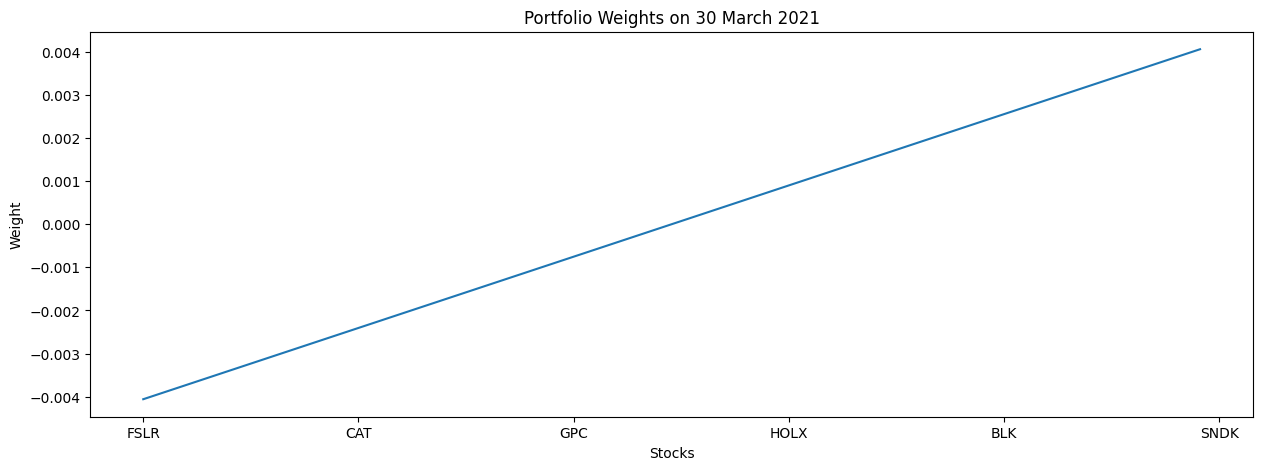

In [5]:
# example portfolio
port.loc['20210330'].sort_values().plot()
plt.title('Portfolio Weights on 30 March 2021')
plt.xlabel('Stocks')
plt.ylabel('Weight')
plt.gcf().set_size_inches(15, 5) # Increase the size of the plot for better visibility
plt.show()

To verify that it is a fully invested portfolio, our row sum should equal to 1, and we can verify this by plotting it below. It should yield a straight horizontal line at 0

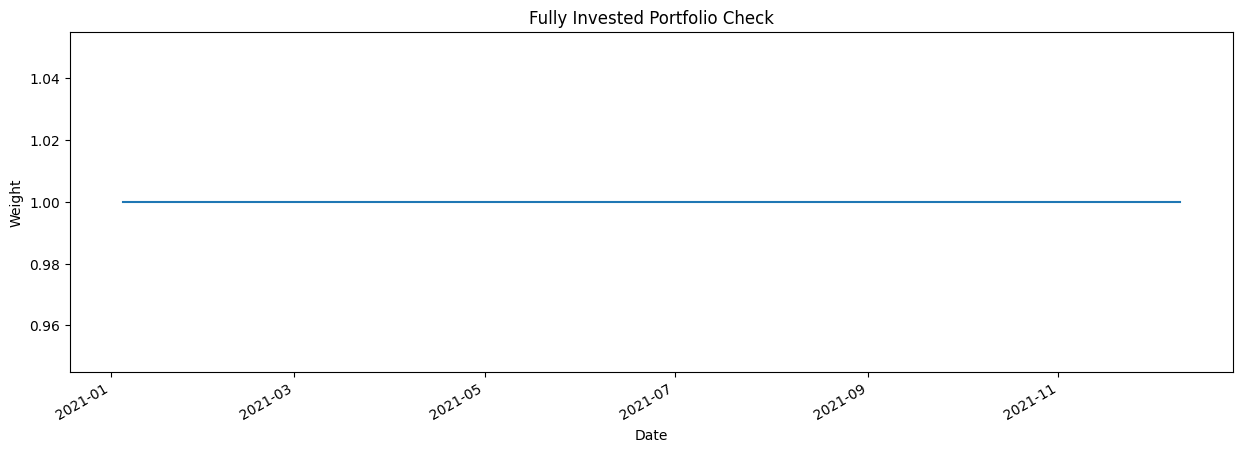

In [6]:
# Fully invested: abs value of port weights should sum to 1
port.abs().sum(1).plot()
plt.title('Fully Invested Portfolio Check')
plt.xlabel('Date')
plt.ylabel('Weight')
plt.gcf().set_size_inches(15, 5) # Increase the size of the plot for better visibility
plt.show()

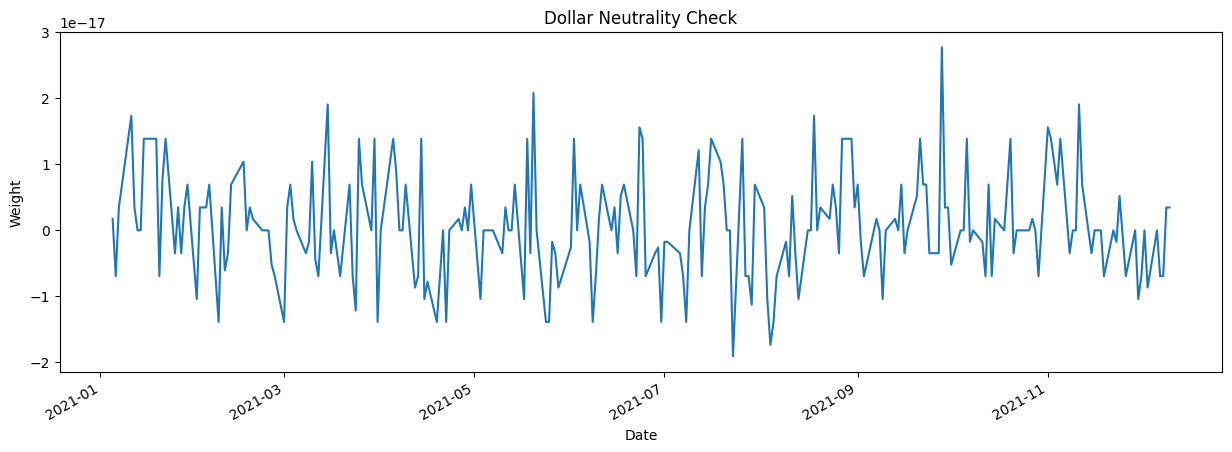

In [7]:
# Dollar neutrality: Port weights should sum to 0
port.sum(1).plot()
plt.title('Dollar Neutrality Check')
plt.xlabel('Date')
plt.ylabel('Weight')
plt.gcf().set_size_inches(15, 5) # Increase the size of the plot for better visibility
plt.show()

### Compute Strategy Returns (Assumming 'Market Order')

We will now compute the strategy returns as shown below: **port** is the portfolio weight matrix, with assets as columns and time as rows.

- Shift the portfolio weights by 1 using port.shift() and multiply it by the returns
- Sum the rows to get the portfolio return for the given day

Rationale: We move all weights one time step forward, so that the weights at time t-1 are used for returns at time t. This ensures no lookahead bias, because we can only earn returns on positions we held before the price changes.

In [8]:
# Compute strategy returns: implicitly assuming "market orders"
# === Rebalance at close, trade next day open (shift forward) ===
strat_ret = (port.shift()*ret).sum(1)
get_stats(strat_ret)

Annualized Return: 9.17%
Annualized Volatility: 6.58%
Sharpe Ratio: 1.39


### Strategy P&L Visualisation

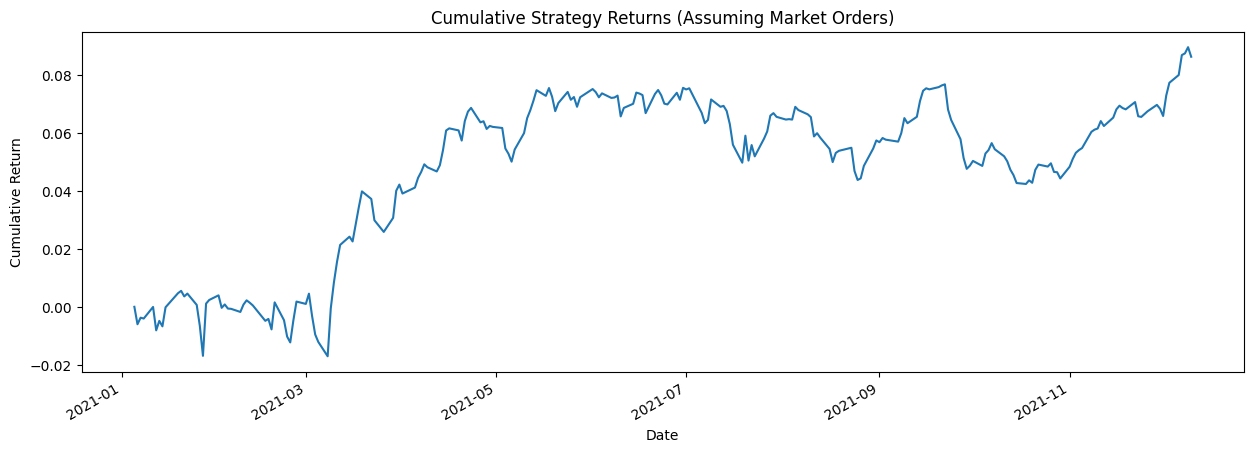

In [9]:
strat_ret.cumsum().plot()
plt.title('Cumulative Strategy Returns (Assuming Market Orders)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.gcf().set_size_inches(15, 5) # Increase the size of the
plt.show()

### Strategy 2: Decile Long-Short (Extreme Momentum)

Create a simple XS 1 day reversal strategy using decile portfolios

Idea: 
> Go long top 10%, short bottom 10% of negative momentum (i.e., worst performers).

Key Features:
- 90/10 Decile Spread
- 50% gross long + 50% gross short → 100% gross exposure
- Dollar neutral: Longs + Shorts = 0
- Sparse: Only ~10% of universe traded



In [10]:
# === Use small signal: -10% of return (attenuates noise) ===
negate = ret*-.1

# === Percentile rank (0 to 1) ===
pct = negate.rank(axis=1,pct=True)

# === Long: Top 10% of negative momentum (worst performers) ===
long = (pct > 0.9)*1
long = long.divide(long.abs().sum(1),0)*0.5 # 50% gross long

# === Short: Bottom 10% (best performers) ===
short = (pct < 0.1)*-1.0
short = short.divide(short.abs().sum(1),0)*0.5 # 50% gross short

# === Combine ===
port = short.add(long,fill_value = 0)

Let us plot the weights across our stocks

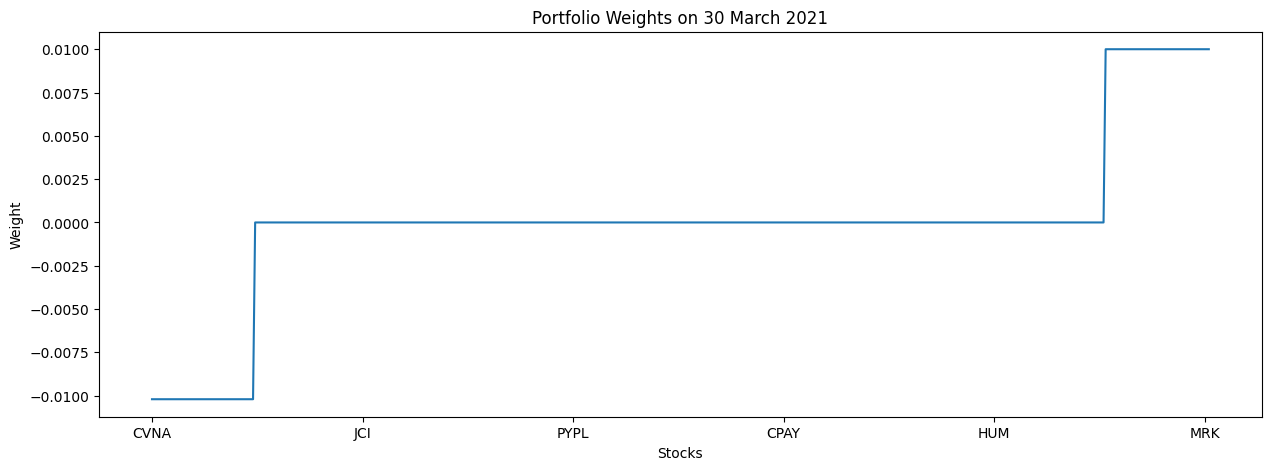

In [11]:
# example portfolio
port.loc['20210330'].sort_values().plot()
plt.title('Portfolio Weights on 30 March 2021')
plt.xlabel('Stocks')
plt.ylabel('Weight')
plt.gcf().set_size_inches(15, 5) # Increase the size of the plot for better visibility
plt.show()

Let us now perform a check on the fully invested portfolio, where the sum of the absolute values of the weights should be equal to 1

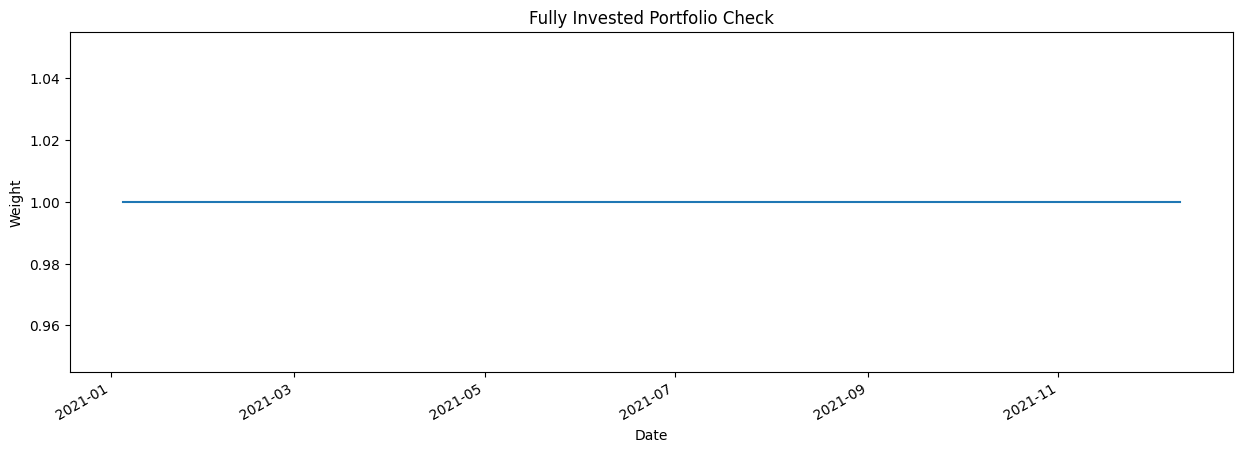

In [12]:
# Fully invested: abs value of port weights should sum to 1
(port.abs()).sum(1).plot()
plt.title('Fully Invested Portfolio Check')
plt.xlabel('Date')
plt.ylabel('Weight')
plt.gcf().set_size_inches(15, 5) # Increase the size of the plot for better visibility
plt.show()

We can also plot the dollar neutrality chart. It should fluctuate slightly due to changing number of stocks in deciles.

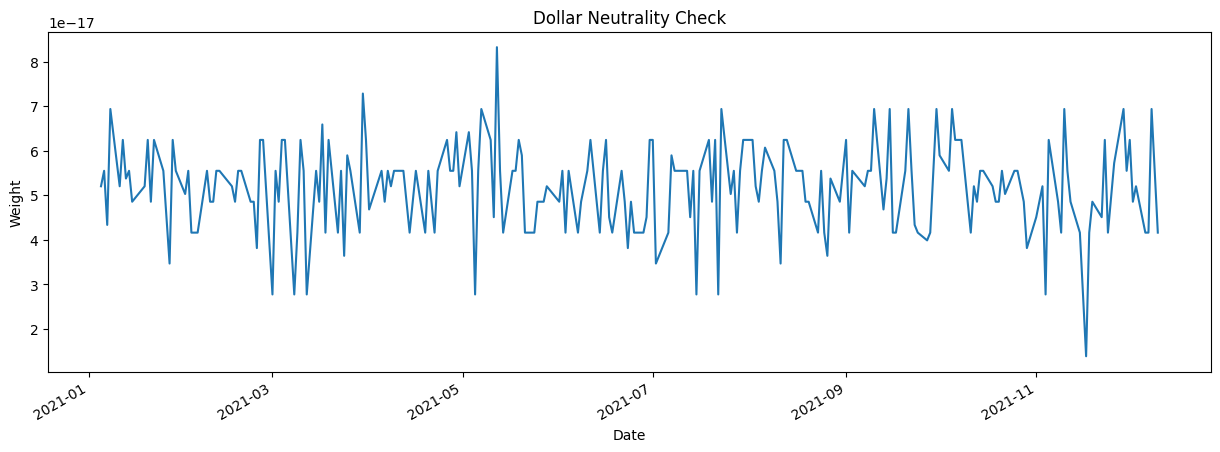

In [13]:
# Dollar neutrality: Port weights should sum to 0
port.sum(1).plot()
plt.title('Dollar Neutrality Check')
plt.xlabel('Date')
plt.ylabel('Weight')
plt.gcf().set_size_inches(15, 5) # Increase the size of the plot for better visibility
plt.show()

### Compute Strategy Returns (Assumming 'Market Order')

In [14]:
# compute strategy returns: implicitly assuming "market orders"
strat_ret = (port.shift()*ret).sum(1)
get_stats(strat_ret)

Annualized Return: 10.63%
Annualized Volatility: 10.71%
Sharpe Ratio: 0.99


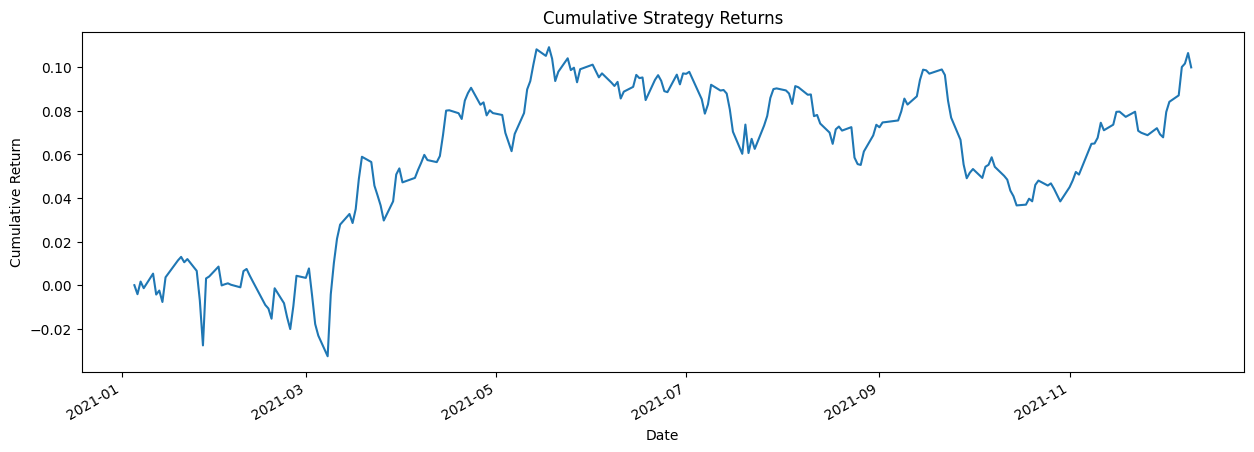

In [15]:
strat_ret.cumsum().plot()
plt.title('Cumulative Strategy Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.gcf().set_size_inches(15, 5) # Increase the size of the plot for better visibility
plt.show()